In [2]:
import numpy as np
import matplotlib.pyplot as plt
import illustris_python as il
import random
import h5py



In [3]:
snapnum = 40

In [4]:
basePath = '/cosma7/data/dp004/dc-zhan5/TNG300-1'

In [5]:
fields = ['GroupFirstSub', "GroupSFR", "GroupMass", "GroupNsubs", 
          "GroupPos", "GroupMassType", "GroupBHMass", "Group_M_TopHat200", "Group_M_Crit200"]
header = il.groupcat.loadHeader(f"{basePath}/output", snapnum)
halos = il.groupcat.loadHalos(f"{basePath}/output", snapnum, fields=fields)

In [6]:
h = 0.6774

In [7]:
mvir = np.log10(halos["Group_M_TopHat200"]*1e10)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [8]:
group_sfr = np.log10(halos["GroupSFR"])

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [9]:
group_pos = halos["GroupPos"]/1e3

In [10]:
fields = ["SubhaloSFR", # [Msun/yr]
          "SubhaloGrNr",
         "SubhaloFlag",
         "SubhaloPos",
         "SubhaloCM", "SubhaloHalfmassRad", "SubhaloHalfmassRadType", "SubhaloMass", "SubhaloBHMass",
         "SubhaloMassType"] # [10^10 Msun/h]
print(len(fields))
subhalos = il.groupcat.loadSubhalos(f"{basePath}/output", snapnum, fields=fields)
print(type(subhalos))

10


<class 'dict'>


In [36]:
mask_mass = (mvir < 13.1) & (mvir > 13)

In [37]:
np.sum(mask_mass)

268

In [38]:
groupids = np.arange(0,len(mvir), 1)[mask_mass]

In [39]:
sub_pos = subhalos["SubhaloPos"]/1e3

In [52]:

bin_edges_nonzero = np.logspace(1, 4, 50)/1e3

In [53]:
seed = 0
np.random.seed(seed)
group_pos1 = group_pos[mask_mass]

shuffled_indices_list = []
shuffled_pos1_list = []
for ibin in range(len(bin_edges_nonzero)-1):
    shuffled_indices = np.arange(0,len(group_pos1))
    np.random.shuffle(shuffled_indices)
    shuffled_pos1 = group_pos1[shuffled_indices]
    shuffled_groupid = groupids[shuffled_indices]
    shuffled_indices_list.append(shuffled_indices)
    shuffled_pos1_list.append(shuffled_pos1)

In [55]:
odir = "tng_toy_models/shuffled_sats_r=0-0.5/logM13.0-13.1/50bins"

ncount = 0
halo_sfrs = [0]*len(shuffled_indices)
with open(f"{odir}/sum_seed{seed}.txt", "w") as f_sum:
    with open(f"{odir}/gal_seed{seed}.txt", "w") as f:
        for ihalo, groupid in enumerate(groupids):
            mask_haloid = (subhalos["SubhaloGrNr"] == groupid) & (subhalos["SubhaloSFR"] > 0)
            pos_rel = sub_pos[mask_haloid] - group_pos[groupid]

            pos_rel_r = np.linalg.norm(pos_rel, axis=1)

            mask_r = (pos_rel_r > 0) & (pos_rel_r < 0.5) 
            #print(np.sum(mask_r))
            #print(len(pos_rel_r))
            #print(np.sum((subhalos["SubhaloGrNr"] == groupid)))

            
            for ibin in range(len(bin_edges_nonzero)-1):
                mask_bin = (pos_rel_r[mask_r] > bin_edges_nonzero[ibin]) &  (pos_rel_r[mask_r] < bin_edges_nonzero[ibin+1])

                pos_arr_new = pos_rel[mask_r][mask_bin] + shuffled_pos1_list[ibin][ihalo]

                #pos_arr_new = pos_rel[mask_r][mask_bin] + group_pos1[ihalo]

                halo_sfrs[shuffled_indices_list[ibin][ihalo]] += np.sum(subhalos["SubhaloSFR"][mask_haloid][mask_r][mask_bin])

           

                for igal in range(np.sum(mask_bin)):
                    #halo_sfrs[ihalo] += 1
                    #halo_sfrs[shuffled_indices_list[ibin][ihalo]] += 1
                    print(groupid, 13, pos_arr_new[:,0][igal], pos_arr_new[:,1][igal], pos_arr_new[:,2][igal], np.log10(subhalos["SubhaloSFR"][mask_haloid][mask_r][mask_bin][igal]), file=f)
                    #print(groupid, 13, pos_arr_new[:,0][igal], pos_arr_new[:,1][igal], pos_arr_new[:,2][igal], 1, file=f)
            
            # mask_in = pos_rel_r[mask_r] < bin_edges_nonzero[0]
            # pos_arr_new = pos_rel[mask_r][mask_in] + shuffled_pos1_list[ibin][ihalo]

            # halo_sfrs[ihalo] += np.sum(subhalos["SubhaloSFR"][mask_haloid][mask_r][mask_in])

            # for igal in range(np.sum(mask_in)):
            #     print(groupid, 13, pos_arr_new[:,0][igal], pos_arr_new[:,1][igal], pos_arr_new[:,2][igal], np.log10(subhalos["SubhaloSFR"][mask_haloid][mask_r][mask_in][igal]), file=f)

            # ngal = np.sum(mask_r)

            # halo_sfr = np.sum(subhalos["SubhaloSFR"][mask_haloid][mask_r])
            
            # mask_test = pos_rel_r < 0.1
            # if np.sum(mask_test) > 1:
            #     ncount+=1
            #     print(np.sum(mask_test))
            # for igal in range(ngal):
            #     print(groupid, 13, pos_arr[:,0][igal], pos_arr[:,1][igal], pos_arr[:,2][igal], np.log10(subhalos["SubhaloSFR"][mask_haloid][mask_r][igal]), file=f)

    for ihalo, groupid in enumerate(groupids):
        print(groupid, 13, group_pos1[:,0][ihalo], group_pos1[:,1][ihalo], group_pos1[:,2][ihalo], np.log10(halo_sfrs[ihalo]), file=f_sum)
        #print(groupid, 13, group_pos1[:,0][ihalo], group_pos1[:,1][ihalo], group_pos1[:,2][ihalo], halo_sfrs[ihalo], file=f_sum)

    

In [83]:
np.sum(halo_sfrs)

14796.849024918862

In [81]:
np.sum(10**group_sfr[mask_mass]-subhalos["SubhaloSFR"][halos["GroupFirstSub"][mask_mass]])

14869.638

In [ ]:
halo_sfrs

[14.663551330566406,
 25.61658477783203,
 24.240902304649353,
 15.297336101531982,
 65.56229639053345,
 145.61103138327599,
 26.60764980316162,
 33.252243757247925,
 154.9138207435608,
 27.281900480389595,
 27.44786412268877,
 41.09242057800293,
 17.626733124256134,
 46.435478925704956,
 33.893863677978516,
 66.15899085998535,
 49.416320979595184,
 58.17182016372681,
 66.1808729171753,
 58.20938420295715,
 111.02147960662842,
 84.65148735046387,
 10.83152449131012,
 62.94798542559147,
 18.42488392814994,
 5.427599549293518,
 76.75143337249756,
 109.98799848556519,
 48.70426386594772,
 17.596070379018784,
 38.73801851272583,
 50.939594864845276,
 40.653690851293504,
 22.753571569919586,
 24.47732302546501,
 48.82838708162308,
 88.47610515356064,
 70.16848766803741,
 58.3466022759676,
 1.142601102590561,
 74.12477397173643,
 28.415276765823364,
 24.117785215377808,
 41.53854179382324,
 9.640834957361221,
 84.16043321788311,
 49.127216247841716,
 11.744614822324365,
 4.486793637275696,
 5

(array([ 2.,  2.,  3., 12., 28., 42., 72., 74., 25.,  8.]),
 array([-0.13799027,  0.11169202,  0.36137432,  0.61105661,  0.86073891,
         1.1104212 ,  1.3601035 ,  1.60978579,  1.85946808,  2.10915038,
         2.35883267]),
 <BarContainer object of 10 artists>)

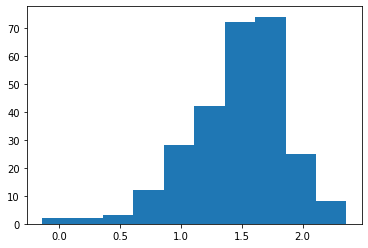

In [78]:
plt.hist(np.log10(halo_sfrs))

(array([ 1.,  1.,  5., 12., 22., 56., 50., 83., 27., 11.]),
 array([0.0578946 , 0.2945872 , 0.53127974, 0.76797235, 1.0046649 ,
        1.2413576 , 1.4780501 , 1.7147427 , 1.9514352 , 2.1881278 ,
        2.4248204 ], dtype=float32),
 <BarContainer object of 10 artists>)

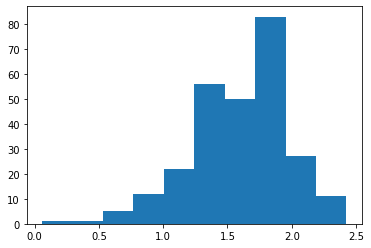

In [50]:
plt.hist(np.log10(10**group_sfr[mask_mass]-subhalos["SubhaloSFR"][halos["GroupFirstSub"][mask_mass]]))